# Customer Churn ML Model

Import files

In [1]:
# ........Install and Import all required libraries.....

import sys
import subprocess

packages = [
    'pandas',
    'numpy',
    'xgboost',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'imbalanced-learn',
    'openpyxl'
]

for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '--quiet'])

print('All Packages Installed')


All Packages Installed


In [156]:
# -------Import Libraries------

# --Core Libraries--
import pandas as pd
import numpy as np

# --Visualization Libraries--
import seaborn as sns
import matplotlib.pyplot as plt

# --ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE



# --- Display Setting
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

print("All Libraries Loaded Successfully")

All Libraries Loaded Successfully


In [157]:
df = pd.read_excel('Customer Churn Dataset.xlsx')
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [158]:
df.shape

(7043, 21)

Dataset Information

In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Data Preprocessing

In [160]:
# Check missing Data

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Column "TotalCharges" has 11 missing datapoints.

In [161]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [162]:
df.TotalCharges.dtype

dtype('float64')

In [163]:
df.TotalCharges.unique()

array([  29.85, 1889.5 ,  108.15, ...,  346.45,  306.6 , 6844.5 ],
      shape=(6531,))

<Axes: >

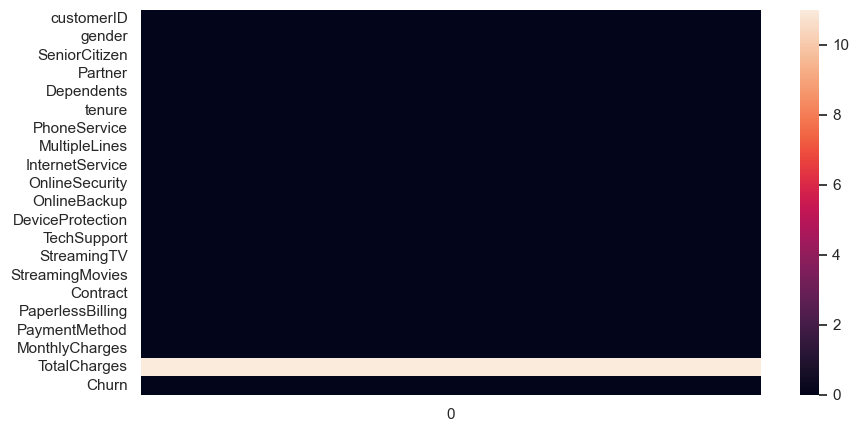

In [164]:
sns.heatmap(df.isnull().sum().to_frame())

In [165]:
# Filling the missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [166]:
# Checking the categorical variables

cat_cols = df.select_dtypes(include = ['object']).columns.tolist()
for col in cat_cols:
    print(f'{col:20s} > {df[col].unique().tolist()}')
    print()

customerID           > ['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU', '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU', '9763-GRSKD', '7469-LKBCI', '8091-TTVAX', '0280-XJGEX', '5129-JLPIS', '3655-SNQYZ', '8191-XWSZG', '9959-WOFKT', '4190-MFLUW', '4183-MYFRB', '8779-QRDMV', '1680-VDCWW', '1066-JKSGK', '3638-WEABW', '6322-HRPFA', '6865-JZNKO', '6467-CHFZW', '8665-UTDHZ', '5248-YGIJN', '8773-HHUOZ', '3841-NFECX', '4929-XIHVW', '6827-IEAUQ', '7310-EGVHZ', '3413-BMNZE', '6234-RAAPL', '6047-YHPVI', '6572-ADKRS', '5380-WJKOV', '8168-UQWWF', '8865-TNMNX', '9489-DEDVP', '9867-JCZSP', '4671-VJLCL', '4080-IIARD', '3714-NTNFO', '5948-UJZLF', '7760-OYPDY', '7639-LIAYI', '2954-PIBKO', '8012-SOUDQ', '9420-LOJKX', '6575-SUVOI', '7495-OOKFY', '4667-QONEA', '1658-BYGOY', '8769-KKTPH', '5067-XJQFU', '3957-SQXML', '5954-BDFSG', '0434-CSFON', '1215-FIGMP', '0526-SXDJP', '0557-ASKVU', '5698-BQJOH', '5122-CYFXA', '8627-ZYGSZ', '3410-YOQBQ', '3170-NMYVV', '7410-OIED

In [167]:
# Drop customer ID
df.drop('customerID', axis=1, inplace=True)

df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [168]:
# Convert 'No phone service' and "No internet service" to "No"
lst = ['No phone service', 'No internet service']

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace(lst, 'No')

# Map the target variable to binary values
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
               'DeviceProtection', 'TechSupport', 'StreamingTV', 
               'StreamingMovies', 'PaperlessBilling']

for col in binary_cols:
    df[col] = df[col].map(binary_map)



In [169]:

# Convert categorical variables to dummy variables, One hot encoding 
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=False)




In [170]:

# convert the target variable to binary values
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


print(f"New Shape of the dataset: {df.shape}")
print(f"\nChurn counts:\n{df['Churn'].value_counts()}")
print(f"\nSample of new columns:\n{df.columns.tolist()}")

New Shape of the dataset: (7043, 27)

Churn counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Sample of new columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [171]:
df.isnull().sum()

gender                                     0
SeniorCitizen                              0
Partner                                    0
Dependents                                 0
tenure                                     0
PhoneService                               0
MultipleLines                              0
OnlineSecurity                             0
OnlineBackup                               0
DeviceProtection                           0
TechSupport                                0
StreamingTV                                0
StreamingMovies                            0
PaperlessBilling                           0
MonthlyCharges                             0
TotalCharges                               0
Churn                                      0
InternetService_DSL                        0
InternetService_Fiber optic                0
InternetService_No                         0
Contract_Month-to-month                    0
Contract_One year                          0
Contract_T

In [172]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,7043.00,0.50,0.50,0.00,0.00,1.00,1.00,1.00
SeniorCitizen,7043.00,0.16,0.37,0.00,0.00,0.00,0.00,1.00
Partner,7043.00,0.48,0.50,0.00,0.00,0.00,1.00,1.00
Dependents,7043.00,0.30,0.46,0.00,0.00,0.00,1.00,1.00
tenure,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
PhoneService,7043.00,0.90,0.30,0.00,1.00,1.00,1.00,1.00
MultipleLines,7043.00,0.42,0.49,0.00,0.00,0.00,1.00,1.00
OnlineSecurity,7043.00,0.29,0.45,0.00,0.00,0.00,1.00,1.00
OnlineBackup,7043.00,0.34,0.48,0.00,0.00,0.00,1.00,1.00
DeviceProtection,7043.00,0.34,0.48,0.00,0.00,0.00,1.00,1.00


Exploratory Data Analysis

Univariate, Bivariate and Multivariate Analysis

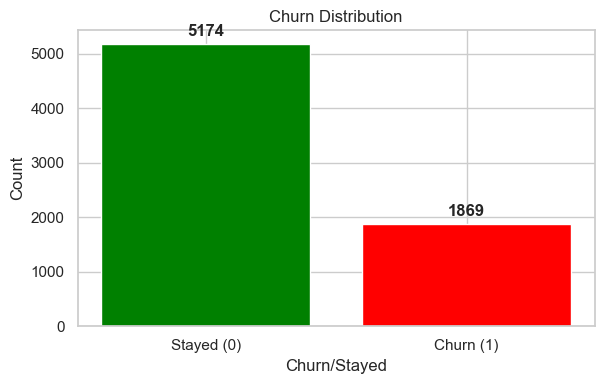

In [173]:
# Churn Distribution
# Determine how many customer churn, and how many customers do not churn. This will help us understand the distribution of the target variable and whether we have a class imbalance problem.

churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(['Stayed (0)', 'Churn (1)'],
         churn_counts.values, 
         color=['green', 'red'])

for i, count in enumerate(churn_counts.values):
    plt.text(i, count + 100, str(count), ha='center', va='bottom', fontweight='bold')
plt.title('Churn Distribution')
plt.xlabel('Churn/Stayed')
plt.tight_layout()
plt.ylabel('Count')
plt.show()

In [174]:
churn_percent = df['Churn'].value_counts()[1] / len(df['Churn']) * 100
print(f"Percentage of customers who churned: {churn_percent:.2f}%")
print(f"Percentage of customers who stayed: {100 - churn_percent:.2f}%")

Percentage of customers who churned: 26.54%
Percentage of customers who stayed: 73.46%


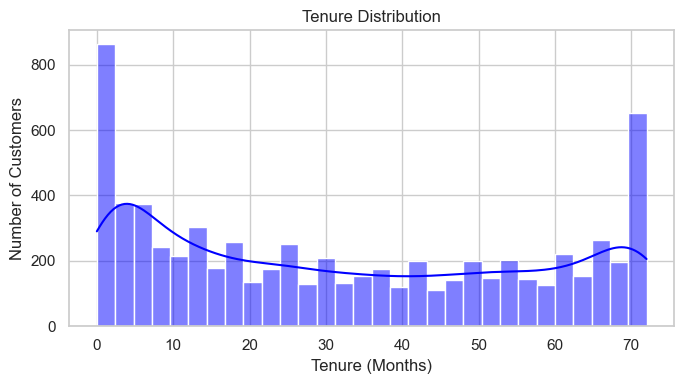

In [175]:
# Tenure distribution
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='tenure', bins=30, kde=True, color='blue')
plt.title('Tenure Distribution')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

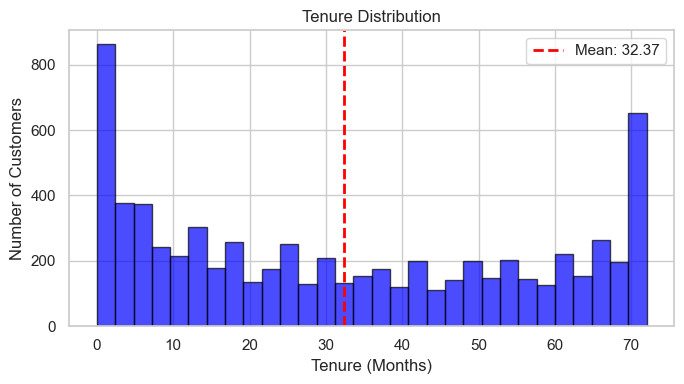

In [176]:
plt.figure(figsize=(7, 4))
plt.hist(df['tenure'], bins=30, color='blue', edgecolor='black', alpha=0.7)
plt.axvline(df['tenure'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df["tenure"].mean():.2f}')
plt.title('Tenure Distribution')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

Histogram plot of the tenure column depicts the period of patronage of the customers. 
It can be seen that about 800+ customers leave so quickly (spent 0-3months), less than 200 spent average months (32months)
While about 650 customers stayed upto 70-72 months.

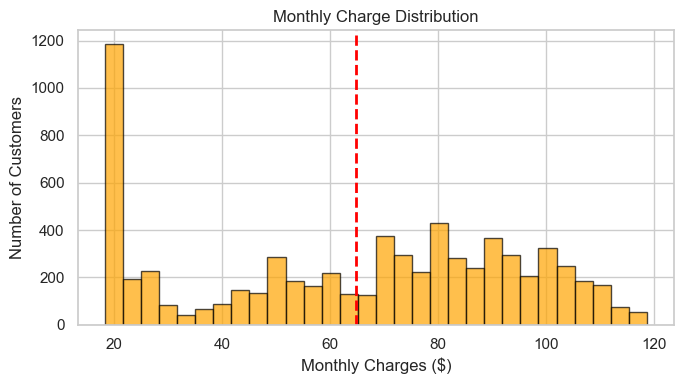

In [177]:
# Monthly charge distribution
plt.figure(figsize=(7, 4))
plt.hist(df['MonthlyCharges'], bins=30, color='orange', edgecolor='black', alpha=0.7)
plt.axvline(df['MonthlyCharges'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df["MonthlyCharges"].mean():.2f}')
plt.title('Monthly Charge Distribution')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

Customers on cheaper monthly plans are more than those on costly monthly plans.

<Axes: ylabel='MonthlyCharges'>

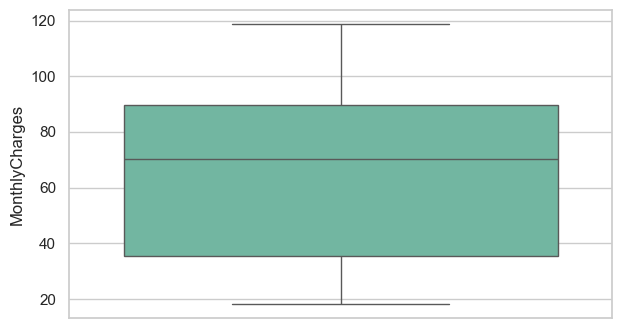

In [178]:
plt.figure(figsize=(7,4))
sns.boxplot(df['MonthlyCharges'])


<Axes: ylabel='tenure'>

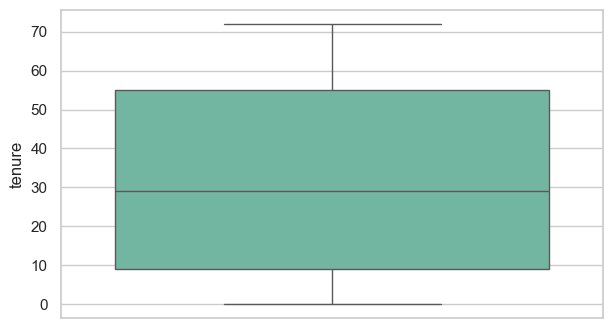

In [179]:
plt.figure(figsize=(7,4))
sns.boxplot(df['tenure'])


TOtal Charges
Lowest: $18.80
Average: $2281.92
Highest: $8684.80


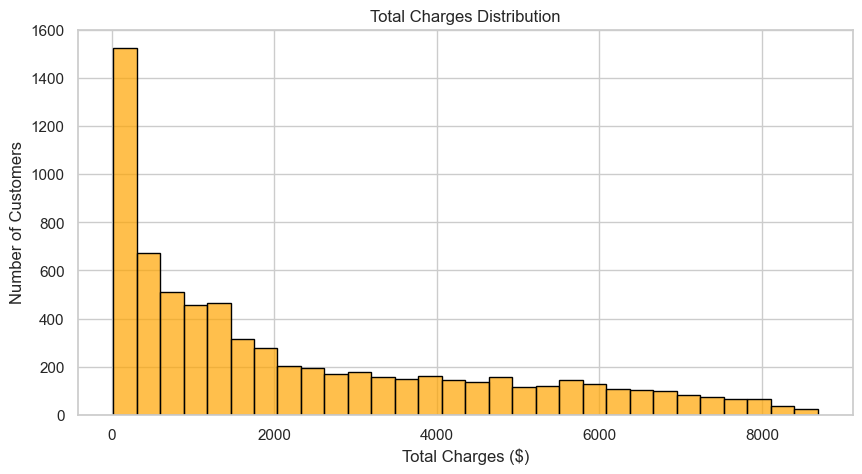

In [180]:
# Distribution of total Charge
sns.histplot(df['TotalCharges'], bins=30, color='orange', edgecolor='black', alpha=0.7)
plt.title('Total Charges Distribution')
plt.xlabel('Total Charges ($)')
plt.ylabel('Number of Customers')

print('TOtal Charges')
print(f'Lowest: ${df['TotalCharges'].min():.2f}')
print(f'Average: ${df['TotalCharges'].mean():.2f}')
print(f'Highest: ${df['TotalCharges'].max():.2f}')

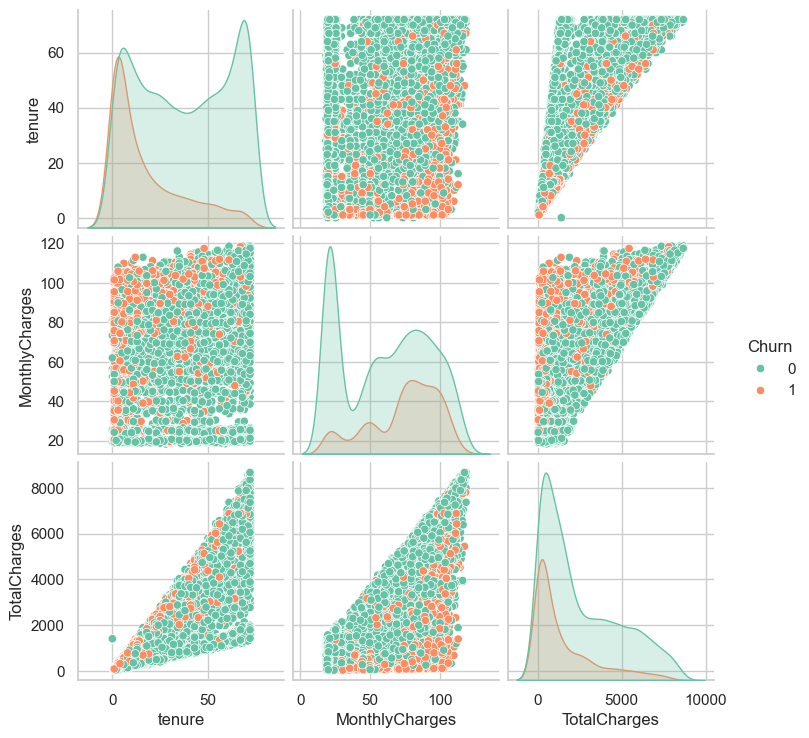

In [181]:
sns.pairplot(df, hue='Churn', vars=['tenure', 'MonthlyCharges', 'TotalCharges'], palette='Set2')
plt.show()

BIVARIATE ANALYSIS

<Figure size 700x400 with 0 Axes>

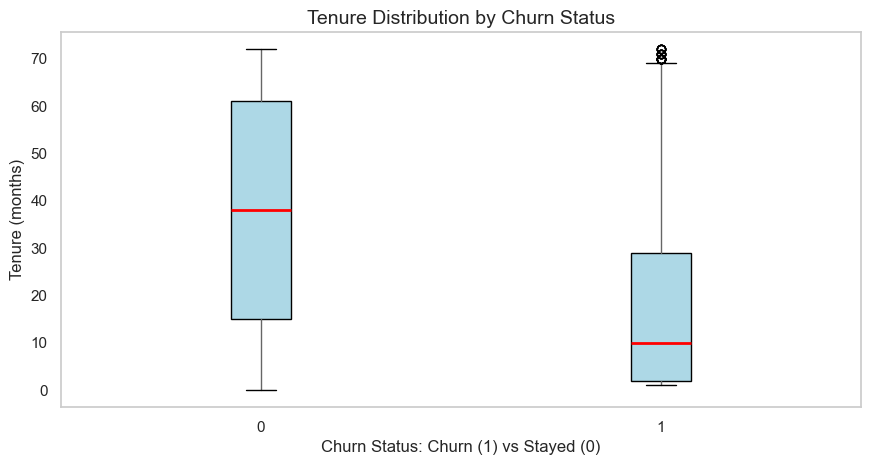

Average tenure by Churn Status:
Churn
0   37.60
1   18.00
Name: tenure, dtype: float64


In [182]:
# Do churner's leave early?
# How long do churners spent before they leave?
# We are answering this question using a boxplot to visualize the relationship between Tenure and Churn. 
# The boxplot will show the distribution of tenure for customers who churned and those who did not churn. 
# This will help us understand if there is a significant difference in tenure between the two groups.

plt.figure(figsize=(7, 4))
df.boxplot(column='tenure', by='Churn', grid=False, 
           patch_artist=True, boxprops=dict(facecolor='lightblue', color='black'),
           medianprops=dict(color='red', linewidth=2))

plt.title('Tenure Distribution by Churn Status', fontsize=14)
plt.suptitle('') # Remove the default title
plt.xlabel('Churn Status: Churn (1) vs Stayed (0)')
plt.ylabel('Tenure (months)')
plt.show()

#Metrics for Tenure by Churn Status
print("Average tenure by Churn Status:")
print(df.groupby('Churn')['tenure'].mean().round(1))

<Figure size 700x400 with 0 Axes>

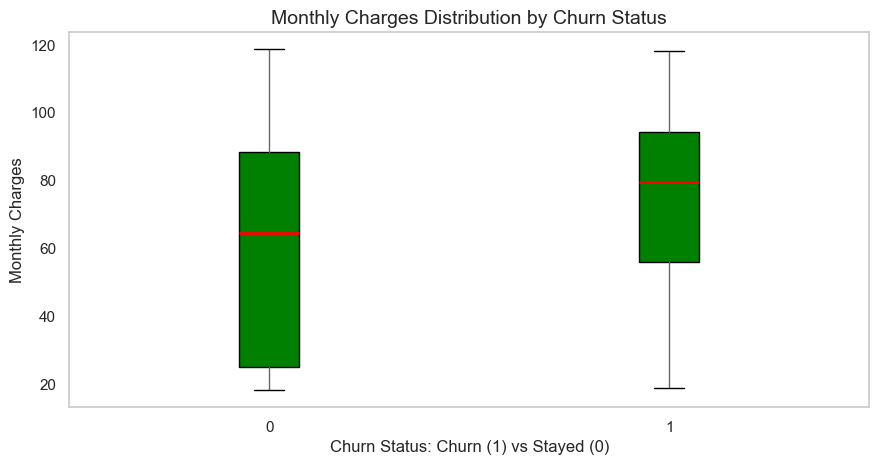

Average monthly charges by Churn Status:
Churn
0   61.30
1   74.40
Name: MonthlyCharges, dtype: float64


In [183]:
# Do customers who pay more churn more?

plt.figure(figsize=(7, 4))
df.boxplot(column='MonthlyCharges', by='Churn', grid=False, 
           patch_artist=True, boxprops=dict(facecolor='green', color='black'),
           medianprops=dict(color='red', linewidth=2))

plt.title('Monthly Charges Distribution by Churn Status', fontsize=14)
plt.suptitle('') # Remove the default title
plt.xlabel('Churn Status: Churn (1) vs Stayed (0)')
plt.ylabel('Monthly Charges')
plt.show()

#Metrics for Monthly Charges by Churn Status
print("Average monthly charges by Churn Status:")
print(df.groupby('Churn')['MonthlyCharges'].mean().round(1))

The boxplot shows that most people who left are high paying customers.

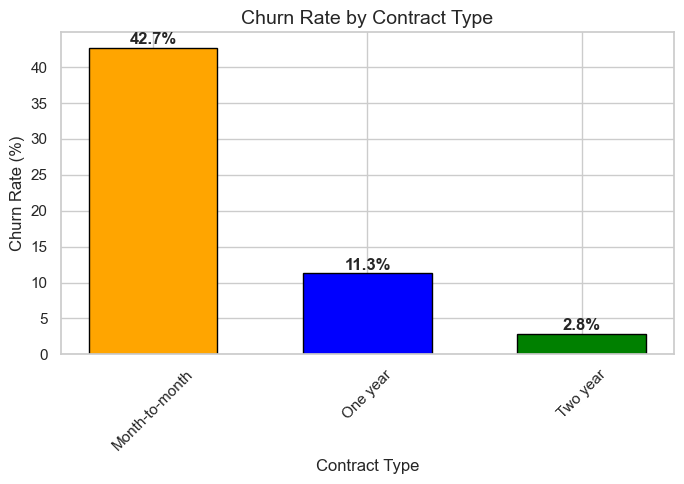

Churn Rate by Contract Type:
Contract_Type
Month-to-month   42.70
One year         11.30
Two year          2.80
Name: Churn, dtype: float64


In [184]:
# contrac type vs churn

contract_churn = df.groupby(['Contract_Month-to-month',
                             'Contract_One year', 
                             'Contract_Two year'])['Churn'].mean()*100

# Better approach

df['Contract_Type']='Month-to-month'
df.loc[df['Contract_One year'] == 1, 'Contract_Type'] = 'One year'
df.loc[df['Contract_Two year'] == 1, 'Contract_Type'] = 'Two year'

churn_by_contract = df.groupby('Contract_Type')['Churn'].mean()*100

plt.figure(figsize=(7, 5))
bars = plt.bar(churn_by_contract.index, churn_by_contract.values,
                color=['orange', 'blue', 'green'],
                edgecolor = 'black', width=0.6)

#Percentage labels on top of the bars
for bar, val in zip(bars, churn_by_contract.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Contract Type', fontsize=14)
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Churn Rate by Contract Type:")
print(churn_by_contract.round(1))

In [185]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Contract_Type'],
      dtype='object')

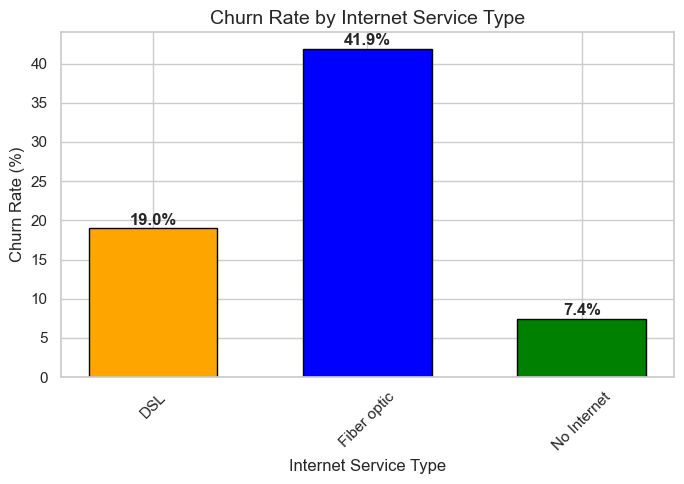

Churn Rate by Internet Service:
Internet_Type
DSL           19.00
Fiber optic   41.90
No Internet    7.40
Name: Churn, dtype: float64


In [186]:

# Grphical representation of churn rate by internet service type

df['Internet_Type']='No Internet'
df.loc[df['InternetService_DSL'] == 1, 'Internet_Type'] = 'DSL'
df.loc[df['InternetService_Fiber optic'] == 1, 'Internet_Type'] = 'Fiber optic'


churn_by_internet = df.groupby('Internet_Type')['Churn'].mean()*100

plt.figure(figsize=(7, 5))
bars = plt.bar(churn_by_internet.index, churn_by_internet.values,
                color=['orange', 'blue', 'green'],
                edgecolor = 'black', width=0.6)

for bar, val in zip(bars, churn_by_internet.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Internet Service Type', fontsize=14)
plt.xlabel('Internet Service Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print("Churn Rate by Internet Service:")
print(churn_by_internet.round(1))


From the analysis of Churn rate by Internet service type, it means, those on Fibre Optics leaves more than those on other service type. Also, the initial analysis shows that those on high service plans churn than every other plan subscribers. 
WHile Fibre optics is costlier than every other internet service, it can be deduce that those on Fibre Type churn due to high service charge rate.

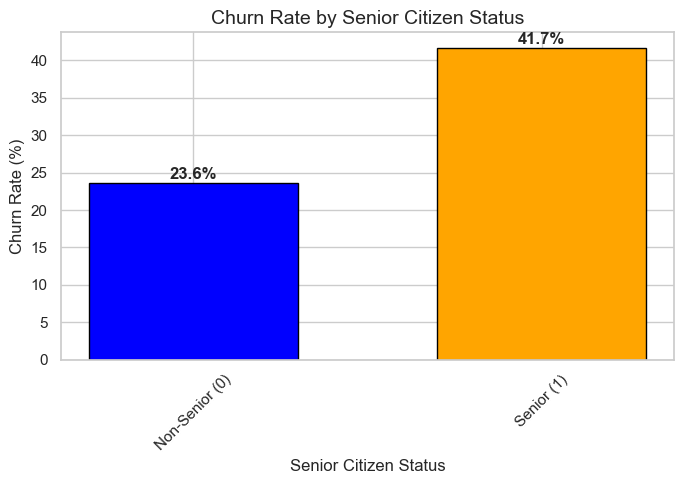

Churn Rate by Senior Citizen Status:
SeniorCitizen
0   23.60
1   41.70
Name: Churn, dtype: float64

Customer Count by Senior Citizen Status:
SeniorCitizen
0    5901
1    1142
dtype: int64


In [187]:
# Senior Citizen

churn_by_senior = df.groupby('SeniorCitizen')['Churn'].mean()*100

plt.figure(figsize=(7, 5))
bars = plt.bar(['Non-Senior (0)', 'Senior (1)'],
                churn_by_senior.values,
                color=['blue', 'orange'],
                edgecolor='black', width=0.6)

for bar, val in zip(bars, churn_by_senior.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Senior Citizen Status', fontsize=14)
plt.xlabel('Senior Citizen Status')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Churn Rate by Senior Citizen Status:")
print(churn_by_senior.round(1))

print("\nCustomer Count by Senior Citizen Status:")
print(df.groupby('SeniorCitizen').size())



In [188]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Contract_Type', 'Internet_Type'],
      dtype='object')

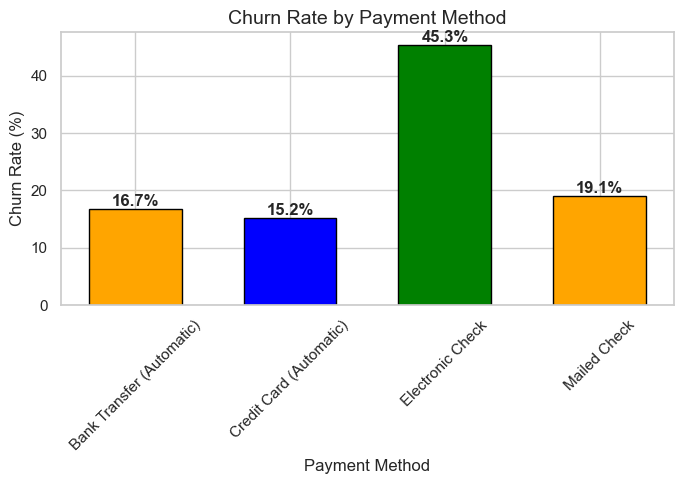

Churn Rate by Payment Method:
Payment_Method
Bank Transfer (Automatic)   16.70
Credit Card (Automatic)     15.20
Electronic Check            45.30
Mailed Check                19.10
Name: Churn, dtype: float64


In [189]:
# Churn by Payment Method


df['Payment_Method'] = 'Bank Transfer (Automatic)'
df.loc[df['PaymentMethod_Credit card (automatic)'] == 1, 'Payment_Method'] = 'Credit Card (Automatic)'
df.loc[df['PaymentMethod_Electronic check'] == 1, 'Payment_Method'] = 'Electronic Check'
df.loc[df['PaymentMethod_Mailed check'] == 1, 'Payment_Method'] = 'Mailed Check'


churn_by_payment_method = df.groupby('Payment_Method')['Churn'].mean()*100

plt.figure(figsize=(7, 5))
bars = plt.bar(churn_by_payment_method.index, churn_by_payment_method.values,
                color=['orange', 'blue', 'green'],
                edgecolor = 'black', width=0.6)

for bar, val in zip(bars, churn_by_payment_method.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Payment Method', fontsize=14)
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Churn Rate by Payment Method:")
print(churn_by_payment_method.round(1))


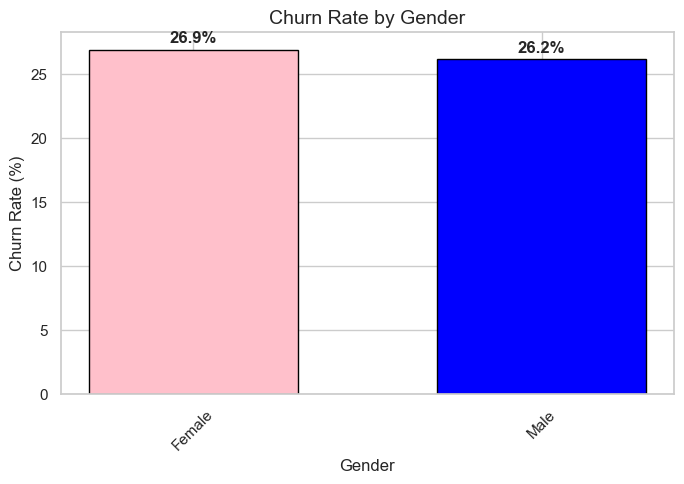

Churn Rate by Gender:
gender
0   26.90
1   26.20
Name: Churn, dtype: float64

Customer Count by Gender:
gender
0    3488
1    3555
dtype: int64


In [190]:
# Churn rate by Gender


churn_by_Gender = df.groupby('gender')['Churn'].mean()*100

plt.figure(figsize=(7, 5))
bars = plt.bar(['Female', 'Male'],
                churn_by_Gender.values,
                color=['pink', 'blue'],
                edgecolor='black', width=0.6)

for bar, val in zip(bars, churn_by_Gender.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Churn Rate by Gender:")
print(churn_by_Gender.round(1))

print("\nCustomer Count by Gender:")
print(df.groupby('gender').size())





Both gender churn at the same rate. It mmeans that gender column has no contribution in our prediction task.

## MULTIVARIATE ANALYSIS

In [191]:
# drop temporary columns used for visualization
df_corr=df.drop(['Contract_Type', 'Internet_Type', 'Payment_Method'], axis=1, inplace=False)


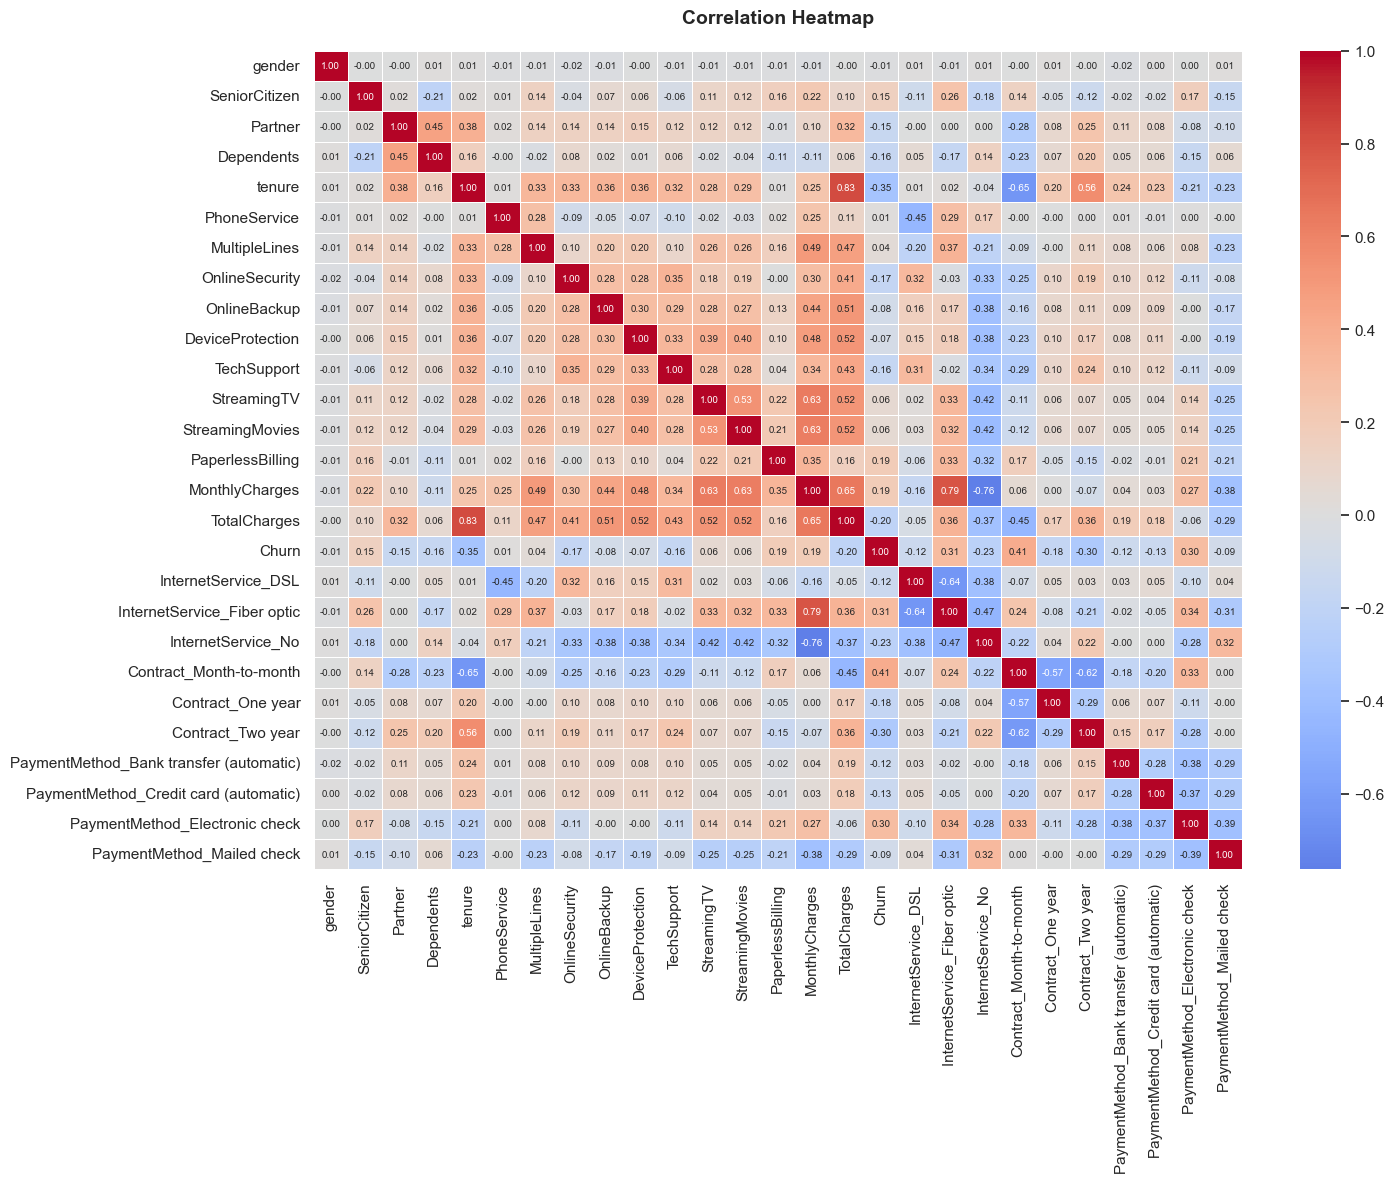

In [192]:

plt.figure(figsize=(15, 12))
sns.heatmap(df_corr.corr(), 
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 7})

plt.title('Correlation Heatmap', 
          fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

In [193]:

print("Correlation with Churn:")
print(df_corr.corr()['Churn'].sort_values(ascending=False).round(2))

Correlation with Churn:
Churn                                      1.00
Contract_Month-to-month                    0.41
InternetService_Fiber optic                0.31
PaymentMethod_Electronic check             0.30
MonthlyCharges                             0.19
PaperlessBilling                           0.19
SeniorCitizen                              0.15
StreamingTV                                0.06
StreamingMovies                            0.06
MultipleLines                              0.04
PhoneService                               0.01
gender                                    -0.01
DeviceProtection                          -0.07
OnlineBackup                              -0.08
PaymentMethod_Mailed check                -0.09
PaymentMethod_Bank transfer (automatic)   -0.12
InternetService_DSL                       -0.12
PaymentMethod_Credit card (automatic)     -0.13
Partner                                   -0.15
Dependents                                -0.16
TechSupport     

FEATURE ENGINEERING

In [194]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Contract_Type', 'Internet_Type', 'Payment_Method'],
      dtype='object')

In [195]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Contract_Type,Internet_Type,Payment_Method
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,True,False,False,True,False,False,False,False,True,False,Month-to-month,DSL,Electronic Check
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.50,0,True,False,False,False,True,False,False,False,False,True,One year,DSL,Mailed Check
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True,Month-to-month,DSL,Mailed Check
3,1,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1840.75,0,True,False,False,False,True,False,True,False,False,False,One year,DSL,Bank Transfer (Automatic)
4,0,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,151.65,1,False,True,False,True,False,False,False,False,True,False,Month-to-month,Fiber optic,Electronic Check


In [196]:
# Add more domain features
df['Avg_monthly_spent'] = df['TotalCharges']/(df['tenure']+1e-5)
df['PayDifference'] = df['MonthlyCharges'] - df['Avg_monthly_spent']




In [197]:
security_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
streaming_cols = ['StreamingTV', 'StreamingMovies']
all_services = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

sec_col_present = [c for c in security_cols if c in df.columns]
str_col_present = [c for c in streaming_cols if c in df.columns]
all_col_present = [c for c in all_services if c in df.columns]

if sec_col_present:
    df['Total_securityServices'] = df[sec_col_present].sum(axis=1)
if str_col_present:
    df['Total_streamServices'] = df[str_col_present].sum(axis=1)
if all_col_present:
    df['TotalServiceCount'] = df[all_col_present].sum(axis=1)
    df['Cost_per_service']=df['TotalCharges']/(df['TotalServiceCount']+1)

In [198]:
if 'InternetService_Fiber optic' in df.columns and 'Contract_Month-to-month' in df.columns:
        df['Risk_Fiber_M2M'] = ((df['InternetService_Fiber optic'] == 1) & 
                                    (df['Contract_Month-to-month'] == 1)).astype(int)
    
    # High Risk 2: Electronic Check Payment + Paperless Billing
if 'PaymentMethod_Electronic check' in df.columns and 'PaperlessBilling' in df.columns:
        df['Risk_ECheck_Paperless'] = ((df['PaymentMethod_Electronic check'] == 1) & 
                                          (df['PaperlessBilling'] == 1)).astype(int)
        
    # High Risk 3: High Monthly Charges without Tech Support
if 'TechSupport' in df.columns:
        median_charge = df['MonthlyCharges'].median()
        df['Risk_HighCost_NoSupport'] = ((df['MonthlyCharges'] > median_charge) & 
                                              (df['TechSupport'] == 0)).astype(int)

In [199]:
df['CustomerValueProxy'] = df['MonthlyCharges'] * df['tenure']

In [200]:
# Create Vertical split
# Create x and y variables for model training

# Feature variables
x = df.drop(['Churn',
             'Contract_Type',
             'Internet_Type',
             'Payment_Method'
             ], axis=1, errors='ignore')

# Target variable
y = df['Churn']


In [201]:
print(f"Shape of x: {x.shape}")
print(f"Shape of y: {y.shape}")
print(f"Sample of x columns:\n{x.columns.tolist()}")
for col in x.columns:
    print(f"{col:20s} > {x[col].dtype}")

print(f"Target Distribution:\n{y.value_counts()}")

Shape of x: (7043, 36)
Shape of y: (7043,)
Sample of x columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'Avg_monthly_spent', 'PayDifference', 'Total_securityServices', 'Total_streamServices', 'TotalServiceCount', 'Cost_per_service', 'Risk_Fiber_M2M', 'Risk_ECheck_Paperless', 'Risk_HighCost_NoSupport', 'CustomerValueProxy']
gender               > int64
SeniorCitizen        > int64
Partner              > int64
Dependents           > int64
tenure               > int64
PhoneService         > i

Training - Testing Split


In [202]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print(f"Split Complete")
print(f"\nTraining Set: {x_train.shape[0]} Customers(80% of total)")
print(f"Test Set: {x_test.shape[0]} Customers(20% of total)")
print(f"\nChurn rate in Training Set: {y_train.mean()*100:.2f}%")
print(f"Churn rate in Test Set: {y_test.mean()*100:.2f}%")

Split Complete

Training Set: 5634 Customers(80% of total)
Test Set: 1409 Customers(20% of total)

Churn rate in Training Set: 26.54%
Churn rate in Test Set: 26.54%


Training XGBClassifier ALgorithm

In [203]:
xgbc = XGBClassifier(random_state=42, eval_metric='logloss')
xgbc.fit(x_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [204]:
# PRedict on the test set
y_pred = xgbc.predict(x_test)

In [205]:
# Evaluation Metrics, using classification report and confusion matrix, roc_auc_score, and confusion matrix display

class_report = classification_report(y_test, y_pred, target_names=['Stayed (0)', 'Churn (1)'])
conf_matrix = confusion_matrix(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)


print(f"Classification Report: ")
print(class_report)
print(f"ROC-AUC: {roc_auc:.4f}")

Classification Report: 
              precision    recall  f1-score   support

  Stayed (0)       0.83      0.88      0.85      1035
   Churn (1)       0.59      0.49      0.54       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.78      0.77      1409

ROC-AUC: 0.6834


In [206]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Contract_Type', 'Internet_Type', 'Payment_Method', 'Avg_monthly_spent',
       'PayDifference', 'Total_securityServices', 'Total_streamServices',
       'TotalServiceCount', 'Cost_per_service', 'Risk_Fiber_M2M',
       'Risk_ECheck_Paperless', 'Risk_HighCost_NoSupport',
       'CustomerValueProxy'],
      dtype='object')

In [207]:
df[['PayDifference', 'Avg_monthly_spent', 'Cost_per_service']]

,PayDifference,Avg_monthly_spent,Cost_per_service
0,0.00,29.85,14.93
1,1.38,55.57,472.38
2,-0.22,54.07,27.04
3,1.39,40.91,460.19
4,-5.12,75.82,75.83
...,...,...,...
7038,1.86,82.94,248.81
7039,0.94,102.26,1051.84
7040,-1.90,31.50,173.22
7041,-2.25,76.65,102.20


Standardscaling
scaling numeric columns

In [208]:
#df['CustomerValueProxy'].dtype

In [209]:
scaler = StandardScaler()

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'PayDifference',
                 'Avg_monthly_spent', 'Cost_per_service']

x_train[numeric_cols] = scaler.fit_transform(x_train[numeric_cols])
x_test[numeric_cols] = scaler.transform(x_test[numeric_cols])

print(x_train[numeric_cols].describe().round(2))

       tenure  MonthlyCharges  TotalCharges  PayDifference  Avg_monthly_spent  \
count 5634.00         5634.00       5634.00        5634.00            5634.00   
mean    -0.00           -0.00         -0.00           0.00              -0.00   
std      1.00            1.00          1.00           1.00               1.00   
min     -1.32           -1.54         -1.00         -26.52              -0.04   
25%     -0.96           -0.97         -0.83           0.04              -0.04   
50%     -0.14            0.18         -0.40           0.04              -0.04   
75%      0.92            0.83          0.67           0.04              -0.04   
max      1.61            1.79          2.80           0.04              26.52   

       Cost_per_service  
count           5634.00  
mean               0.00  
std                1.00  
min               -1.30  
25%               -0.91  
50%               -0.12  
75%                0.75  
max                5.45  


In [210]:
# Apply SMOTE to balance the classes in the training set
smote = SMOTE(random_state=42, sampling_strategy=0.8, k_neighbors=10)

x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print(f"Before SMOTE, Training Set: {x_train.shape[0]} Customers")
print(f"Before SMOTE, Training Set (Churn): {y_train.sum()} Customers")

print(f"After SMOTE, Training Set: {x_train_smote.shape[0]} Customers")
print(f"After SMOTE, Training Set (Churn): {y_train_smote.sum()} Customers")


Before SMOTE, Training Set: 5634 Customers
Before SMOTE, Training Set (Churn): 1495 Customers
After SMOTE, Training Set: 7450 Customers
After SMOTE, Training Set (Churn): 3311 Customers


In [211]:
print(f"Before Smote, No of Churn customers: {y_train.sum()}/{x_train.shape[0]} ({y_train.mean()*100:.2f}%)")
print(f"After Smote, No of Churn customers: {y_train_smote.sum()}/{x_train_smote.shape[0]} ({y_train_smote.mean()*100:.2f}%)")

Before Smote, No of Churn customers: 1495/5634 (26.54%)
After Smote, No of Churn customers: 3311/7450 (44.44%)


PCA

In [212]:
from sklearn.decomposition import PCA
pca_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
pca = PCA(random_state=42, n_components=2)
train_pca = pca.fit_transform(x_train_smote[pca_cols])
test_pca = pca.fit_transform(x_test[pca_cols])

# Add to dataframe
x_train_smote['pca_com1'] = train_pca[:,0]
x_train_smote['pca_com2'] = train_pca[:,1]

x_test['pca_com1'] = test_pca[:,0]
x_test['pca_com2'] = test_pca[:,1]

# Variance analysis
print(f'Variance Analysis:\n {pca.explained_variance_ratio_}')
print(f"Total Variance Retained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

Variance Analysis:
 [0.71021863 0.26852749]
Total Variance Retained: 97.87%


ML-DEVELOPMENT PHASE

In [213]:
# Logistic Regression Model

#Build and train the logistic regression model on the balanced training set
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(x_train_smote, y_train_smote)


c:\Users\PHOTON\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [214]:
# Predict on the test set using the logistic regression model
y_pred_lr = lr_model.predict(x_test)
lr_proba = lr_model.predict_log_proba(x_test)[:, 1]

In [215]:
# Evaluation 
print("=" * 50)
print(" MODEL 1: LOGISTIC REGRESSION RESULTS")
print("=" * 50)

print("Classification Report:")
print(classification_report(y_test, y_pred_lr, 
                            target_names=['No Churn (0)', 'Churn (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_proba):.4f}")

 MODEL 1: LOGISTIC REGRESSION RESULTS
Classification Report:
              precision    recall  f1-score   support

No Churn (0)       0.86      0.85      0.85      1035
   Churn (1)       0.60      0.62      0.61       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409

ROC-AUC Score: 0.8397


Hyperparameter TUning of Logostic REgression

In [218]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform


lr_model2 = LogisticRegression(random_state=42, max_iter=1000)

param_grid = {
    "C": loguniform(1e-3, 1e2),
    "class_weight": [None, "balanced"],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

random_search = RandomizedSearchCV(estimator=lr_model2,
                                   param_distributions=param_grid,
                                   n_iter=10,
                                   cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                                   scoring='roc_auc',
                                   n_jobs=-1,
                                   random_state=42)


random_search.fit(x_train_smote, y_train_smote)

c:\Users\PHOTON\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\PHOTON\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': <scipy.stats....002D43ABDE5D0>, 'class_weight': [None, 'balanced'], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versi

In [219]:
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

Best Parameters: {'C': np.float64(1.0129197956845732), 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Best Score: 0.9216156844756809


In [220]:
best_lr = random_search.best_estimator_
y_pred_lr_new = best_lr.predict(x_test)

In [221]:
# Evaluation 
print("=" * 50)
print(" MODEL 1: LOGISTIC REGRESSION RESULTS")
print("=" * 50)

print("Classification Report:")
print(classification_report(y_test, y_pred_lr_new, 
                            target_names=['No Churn (0)', 'Churn (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, best_lr.predict_log_proba(x_test)[:, 1]):.4f}")

 MODEL 1: LOGISTIC REGRESSION RESULTS
Classification Report:
              precision    recall  f1-score   support

No Churn (0)       0.89      0.78      0.83      1035
   Churn (1)       0.55      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409

ROC-AUC Score: 0.8406


Base model of Logistic REgression performs excellent than the hyperparameter tuned model

In [70]:
# RANDOM FOREST CLASSIFIER
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train_smote, y_train_smote)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [71]:
# Make predictions on the test set using the random forest model
y_pred_rf = rf_model.predict(x_test)
rf_proba = rf_model.predict_proba(x_test)[:, 1]


In [72]:
# Evaluate the model performance using classification report and confusion matrix
 
print("=" * 50)
print(" MODEL 2: RANDOM FOREST RESULTS")
print("=" * 50)

print("Classification Report:")
print(classification_report(y_test, y_pred_rf, 
                            target_names=['No Churn (0)', 'Churn (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_proba):.4f}")

 MODEL 2: RANDOM FOREST RESULTS
Classification Report:
              precision    recall  f1-score   support

No Churn (0)       0.86      0.82      0.84      1035
   Churn (1)       0.55      0.63      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409

ROC-AUC Score: 0.8238


In [73]:
# XGBoost Classifier
xgb_c = XGBClassifier()
xgb_c.fit(x_train_smote, y_train_smote)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [74]:
# Prediction
y_pred_xgb = xgb_c.predict(x_test)
xgb_proba = xgb_c.predict_proba(x_test)[:, 1]

print("=" * 50)
print(" MODEL 3: XGBOOST RESULTS")
print("=" * 50)

print("Classification Report:")
print(classification_report(y_test, y_pred_xgb, 
                            target_names=['No Churn (0)', 'Churn (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_xgb):.4f}")

 MODEL 3: XGBOOST RESULTS
Classification Report:
              precision    recall  f1-score   support

No Churn (0)       0.85      0.81      0.83      1035
   Churn (1)       0.54      0.61      0.57       374

    accuracy                           0.76      1409
   macro avg       0.70      0.71      0.70      1409
weighted avg       0.77      0.76      0.76      1409

ROC-AUC Score: 0.7123


C:\Users\PHOTON\AppData\Local\Temp\ipykernel_14708\3372384294.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='Set2')


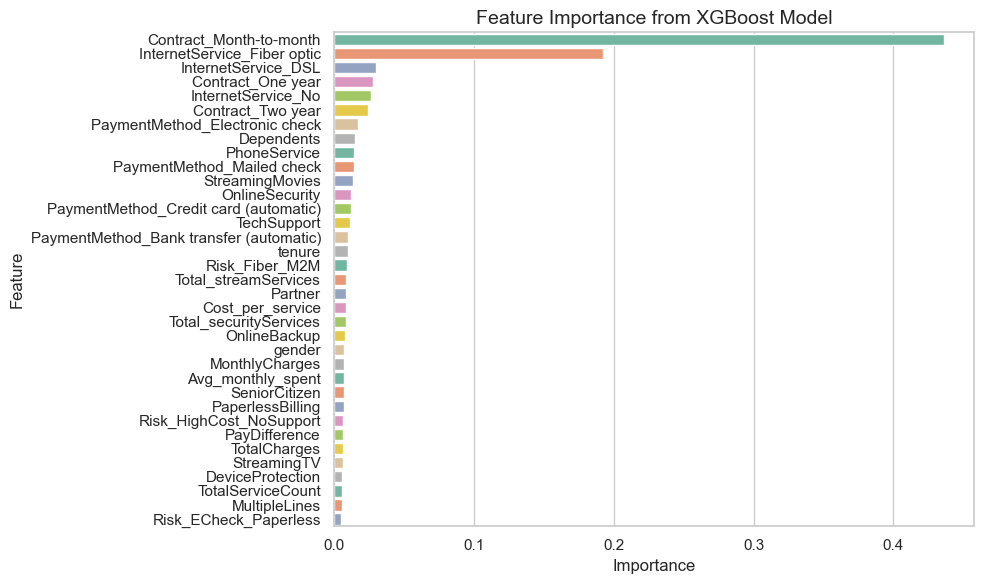

In [76]:
# Feature importance from XGBoost model
feature_importance = pd.DataFrame({'Feature': x_train_smote.columns,
                                   'Importance': xgb_c.feature_importances_})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

# Plot the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='Set2')
plt.title('Feature Importance from XGBoost Model', fontsize=14)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

HYPERPARAMETER TUNING

In [420]:
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK, space_eval

space={'max_depth': hp.quniform("max_depth", 3, 18, 1),
        'gamma': hp.uniform ('gamma', 1,9),
        'reg_alpha' : hp.quniform('reg_alpha', 40,180,1),
        'reg_lambda' : hp.uniform('reg_lambda', 0,1),
        'colsample_bytree' : hp.uniform('colsample_bytree', 0.5,1),
        'min_child_weight' : hp.quniform('min_child_weight', 0, 10, 1),
        'n_estimators': 180,
        'seed': 0
    }

def objective(space):
    clf=XGBClassifier(
                    n_estimators =space['n_estimators'], 
                    max_depth = int(space['max_depth']), 
                    gamma = space['gamma'],
                    reg_alpha = int(space['reg_alpha']),
                    reg_lambda = space['reg_lambda'],
                    min_child_weight=int(space['min_child_weight']),
                    colsample_bytree=int(space['colsample_bytree']))

    accuracy = cross_val_score(clf, x_train_smote, y_train_smote, scoring='precision', cv=5).mean()
    return {'loss': -accuracy, 'status': STATUS_OK } 


In [421]:
trials = Trials()
best_hyper = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials
)

best_params = space_eval(space, best_hyper)

best_params['max_depth'] = int(best_params['max_depth'])
best_params['reg_alpha'] = int(best_params['reg_alpha'])
best_params['min_child_weight'] = int(best_params['min_child_weight'])

print("\n" + "=" * 50)
print("BEST HYPERPARAMETERS FOUND: ")
print("="*50)
for k, v in best_params.items():
    print(f"{k}: {v}")

100%|██████████| 50/50 [01:27<00:00,  1.75s/trial, best loss: -0.7615706159577951]

BEST HYPERPARAMETERS FOUND: 
colsample_bytree: 0.5168014950572828
gamma: 1.9152425219956046
max_depth: 9
min_child_weight: 0
n_estimators: 180
reg_alpha: 42
reg_lambda: 0.5277221279020488
seed: 0


In [422]:
XGBest_model = XGBClassifier(**best_params)
XGBest_model.fit(x_train_smote, y_train_smote)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5168014950572828
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

In [424]:
y_pred_xgb2 = XGBest_model.predict(x_test)
xgb_proba = XGBest_model.predict_proba(x_test)[:, 1]

print("=" * 50)
print(" MODEL 3: XGBOOST RESULTS")
print("=" * 50)

print("Classification Report:")
print(classification_report(y_test, y_pred_xgb2, 
                            target_names=['No Churn (0)', 'Churn (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, xgb_proba):.4f}")

 MODEL 3: XGBOOST RESULTS
Classification Report:
              precision    recall  f1-score   support

No Churn (0)       0.90      0.74      0.81      1035
   Churn (1)       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC Score: 0.8341


After hyperparameter tuning of XGBoost classifier using Hyperopt, 
the precision of No churn increases from 0.85 to 0.90 and 
the Recall for Churn increases to 0.76 from 0.61. 
But the Recall score of No Churn dropped from 0.81 to 0.74.

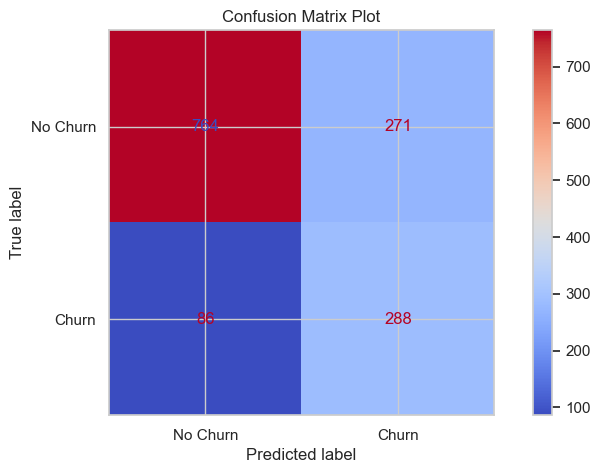

In [ ]:
cm = confusion_matrix(y_test, y_pred_xgb2)
conf_matr = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                   display_labels=['No Churn', 'Churn'])
conf_matr.plot(cmap='coolwarm')
plt.title('Tuned XGBoost Confusion Matrix Plot')
plt.show()

SUPPORT VECTOR CLASSIFIER

In [ ]:
# SUPPORT VECTOR CLASSIFIER

#from sklearn.svm import SVC

#svc_model = SVC(probability=True)
#svc_model.fit(x_train_smote, y_train_smote)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
# Predict on SVC model

#y_pred_svc=svc_model.predict(x_test)
#svc_proba = svc_model.predict_proba(x_test)[:, 1]

print("=" * 50)
print(" MODEL 4: SVC RESULTS")
print("=" * 50)

print("Classification Report:")
print(classification_report(y_test, y_pred_svc, 
                            target_names=['No Churn (0)', 'Churn (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, svc_proba):.4f}")


 MODEL 4: SVC RESULTS
Classification Report:
              precision    recall  f1-score   support

No Churn (0)       0.90      0.75      0.82      1035
   Churn (1)       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409

ROC-AUC Score: 0.8282


In [75]:
# SVC Hyperparameter Tuning

svc_space = {
    'C': hp.loguniform('C', np.log(0.01), np.log(100)),
    'kernel': hp.choice('kernel', ['rbf', 'linear', 'sigmoid']),
    'gamma': hp.choice('gamma', ['scale', 'auto']),
    'class_weight': hp.choice('class_weight', [None, 'balanced']),
    'random_state': 42
}

def objective(space):
    clf = SVC(
        C=space['C'],
        kernel=space['kernel'],
        gamma=space['gamma'],
        class_weight=space['class_weight'],
        probability=True,
        random_state=space['random_state']
    )
    
    score = cross_val_score(clf, x_train_smote,
                            y_train_smote, cv=5, 
                            scoring='roc_auc').mean()
    return {'loss': -score, 'status': STATUS_OK}

# Running the Optimization
trials = Trials()
best_hyper = fmin(
    fn=objective,
    space=svc_space,
    algo=tpe.suggest,
    max_evals=30,
    trials=trials
)

# print best parameters
best_svc_params = space_eval(svc_space, best_hyper)

print("=" * 50)
print("BEST SVM PARAMETERS FOUND:")
print("=" * 50)
for k, v in best_svc_params.items():
    print(f"{k}: {v}")


  0%|          | 0/30 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 30/30 [2:00:51<00:00, 241.71s/trial, best loss: -0.8984143549648476]   
BEST SVM PARAMETERS FOUND:
C: 65.27039519655004
class_weight: balanced
gamma: scale
kernel: linear
random_state: 42


In [ ]:
# 5. Train & Evaluate Final SVM Model using existing x_train and x_test
final_svc = SVC(**best_svc_params, probability=True)
final_svc.fit(x_train_smote, y_train_smote)

# Prediction on the final svc
y_pred_svc2 = final_svc.predict(x_test)
svc_proba2 = final_svc.predict_proba(x_test)[:,1]

# Evaluation
print("="*50)
print("SUPPORT VECTOR CLASSIFIER PERFORMANCE")
print("="*50)

print(f"Classification Report: ")
print(classification_report(y_test, y_pred_svc2,
                            target_names=['No Churn (0)', 'Churn (1)']))
print(f"\nROC-AUC:{roc_auc_score(y_test, svc_proba2):.4f} ")

SUPPORT VECTOR CLASSIFIER PERFORMANCE
Classification Report: 
              precision    recall  f1-score   support

No Churn (0)       0.92      0.65      0.76      1035
   Churn (1)       0.46      0.85      0.60       374

    accuracy                           0.70      1409
   macro avg       0.69      0.75      0.68      1409
weighted avg       0.80      0.70      0.72      1409


ROC-AUC:
0.8361 


Hyperparameter Tuning of all the models demonstrated a higher Precision score for No Churn, higher Recall but lower precision score for Churn prediction.